# Task 4: Double Down Analysis

This analysis explores the "Double Down" ability. We evaluate:
1. Which categories are chosen most frequently for a double down?
2. Which levels are chosen most frequently for a double down?
3. How does the number of active skills affect the decision to double down?
4. How do these factors differ between `Control` runs and `Tool` runs?
5. How does the `Tool` mode's double down selection compare against its overall baseline distribution?

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import fisher_exact

# Helper to run 2x2 Fisher's Exact Test for each unique value (One vs Rest)
def print_fisher_results(series1, series2, group1_name, group2_name, label):
    print(f"\n--- Fisher's Exact Test: {label} ({group1_name} vs {group2_name}) ---")
    unique_vals = set(series1.dropna().unique()).union(set(series2.dropna().unique()))
    n1, n2 = len(series1), len(series2)
    
    if n1 == 0 or n2 == 0:
        print("Not enough data to run Fisher's Exact Test.")
        return

    results = []
    for val in unique_vals:
        k1 = (series1 == val).sum()
        k2 = (series2 == val).sum()
        
        # 2x2 Contingency Table:  Is Val / Not Val  x  Group1 / Group2
        table = [[k1, k2], [n1 - k1, n2 - k2]]
        _, p_val = fisher_exact(table)
        
        results.append({
            'Value': val,
            f'{group1_name}': f"{k1}/{n1} ({k1/n1*100:.1f}%)",
            f'{group2_name}': f"{k2}/{n2} ({k2/n2*100:.1f}%)",
            'p-value': p_val,
            'Significant': 'Yes' if p_val < 0.05 else 'No'
        })
    
    df_res = pd.DataFrame(results).sort_values('p-value')
    display(df_res)
    print("-" * 60)

# Load Double Down data
with open('../scripts/parsed_task4.json', 'r') as f:
    dd_data = json.load(f)
df_dd = pd.DataFrame(dd_data)

if df_dd.empty:
    print("No double down actions found.")
else:
    print(f"Loaded {len(df_dd)} Double Down events.")
    
    # Load Overall Baseline data
    with open('../scripts/parsed_data.json', 'r') as f:
        all_data = json.load(f)
        
    all_tool_categories = []
    all_tool_levels = []
    for r in all_data:
        if r['mode'] == 'tool':
            for q in r['questions_attempted']:
                all_tool_categories.append(q['category'])
                all_tool_levels.append(int(q['level']))
                
    # Split by mode for comparisons
    df_dd_control = df_dd[df_dd['mode'] == 'control']
    df_dd_tool = df_dd[df_dd['mode'] == 'tool']

Loaded 299 Double Down events.


## 4.1 Category and Level Selection: Control vs Tool
Compares which categories and difficulty levels are chosen for Double Down between Control and Tool mode, with Fisher's Exact tests per value.


--- Fisher's Exact Test: Double Down Category (Control vs Tool) ---


,Value,Control,Tool,p-value,Significant
3,"Language, Linguistics & Cryptography",8/131 (6.1%),2/168 (1.2%),0.023882,Yes
4,Pop Culture & Entertainment,7/131 (5.3%),19/168 (11.3%),0.096728,No
2,Geography & Travel,6/131 (4.6%),3/168 (1.8%),0.186821,No
0,Science & Mathematics,78/131 (59.5%),112/168 (66.7%),0.226696,No
1,Technology & Computer Science,21/131 (16.0%),20/168 (11.9%),0.314501,No
5,History & Politics,5/131 (3.8%),4/168 (2.4%),0.511882,No
6,"Arts, Literature & Museums",6/131 (4.6%),8/168 (4.8%),1.000000,No


------------------------------------------------------------

--- Fisher's Exact Test: Double Down Level (Control vs Tool) ---


,Value,Control,Tool,p-value,Significant
2,3,27/131 (20.6%),46/168 (27.4%),0.221944,No
0,1,31/131 (23.7%),31/168 (18.5%),0.314662,No
1,2,73/131 (55.7%),91/168 (54.2%),0.815506,No


------------------------------------------------------------


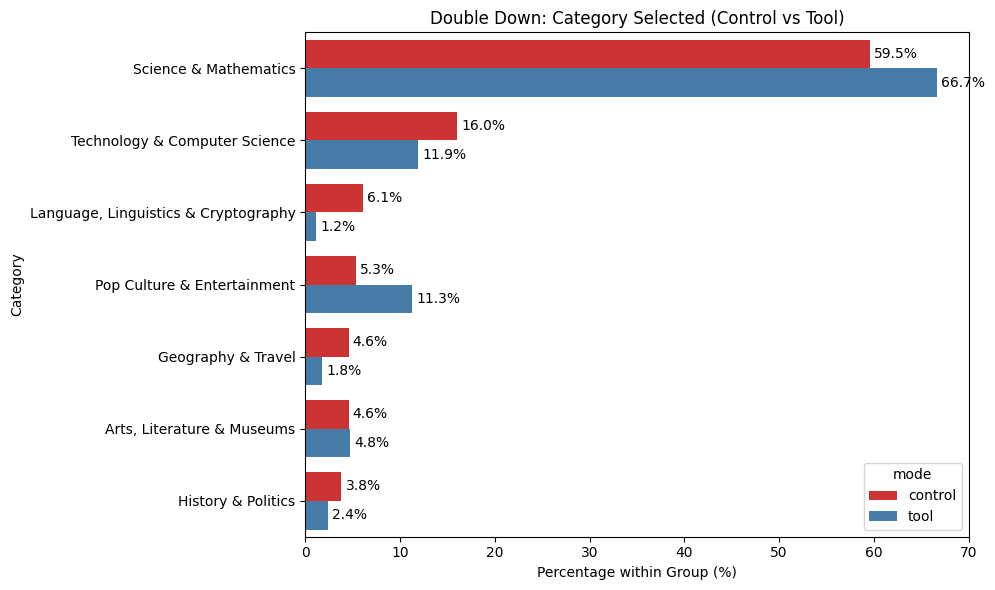

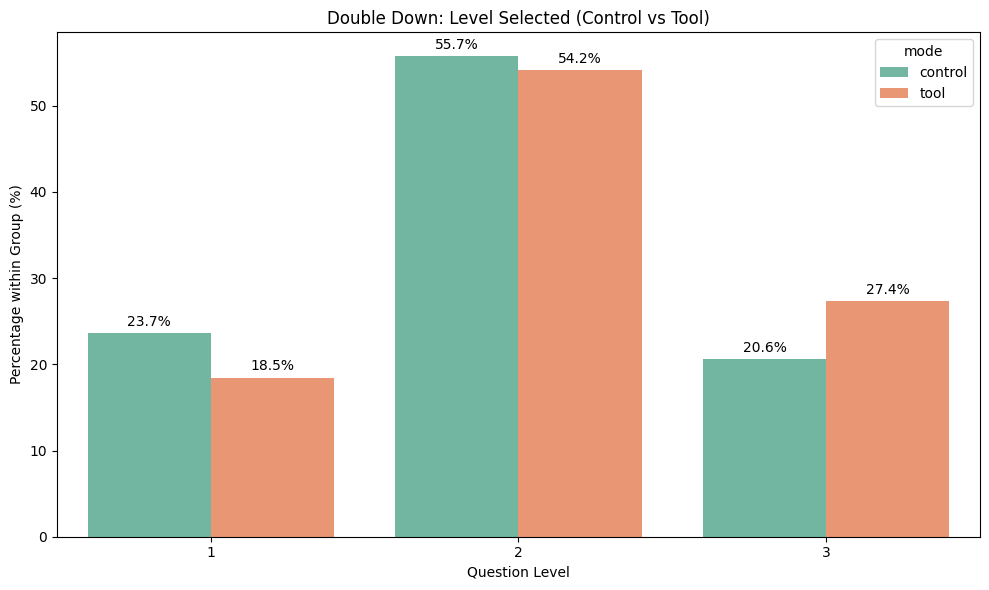

In [14]:
# Fisher Tests: Control vs Tool (Double Down)
print_fisher_results(df_dd_control['category'], df_dd_tool['category'], 'Control', 'Tool', 'Double Down Category')
print_fisher_results(df_dd_control['level'], df_dd_tool['level'], 'Control', 'Tool', 'Double Down Level')

# ==========================================================
# 1. Compare Control vs Tool: Double Down CATEGORY (Percentage)
# ==========================================================
cat_pct = df_dd.groupby('mode')['category'].value_counts(normalize=True).rename('Percentage').reset_index()
cat_pct['Percentage'] *= 100

plt.figure(figsize=(10, 6))
ax1 = sns.barplot(data=cat_pct, y='category', x='Percentage', hue='mode', palette='Set1')
plt.title('Double Down: Category Selected (Control vs Tool)')
plt.xlabel('Percentage within Group (%)')
plt.ylabel('Category')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

# ==========================================================
# 2. Compare Control vs Tool: Double Down LEVEL (Percentage)
# ==========================================================
lvl_pct = df_dd.groupby('mode')['level'].value_counts(normalize=True).rename('Percentage').reset_index()
lvl_pct['Percentage'] *= 100

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(data=lvl_pct, x='level', y='Percentage', hue='mode', palette='Set2')
plt.title('Double Down: Level Selected (Control vs Tool)')
plt.xlabel('Question Level')
plt.ylabel('Percentage within Group (%)')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

## 4.2 Active Skills Count During Double Down (Tool Mode)
Examines how many skills were active at the time of each Double Down decision in Tool mode.

/tmp/ipykernel_9648/2221936683.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data=skills_pct, x='active_skills_count', y='Percentage', palette='Set3')


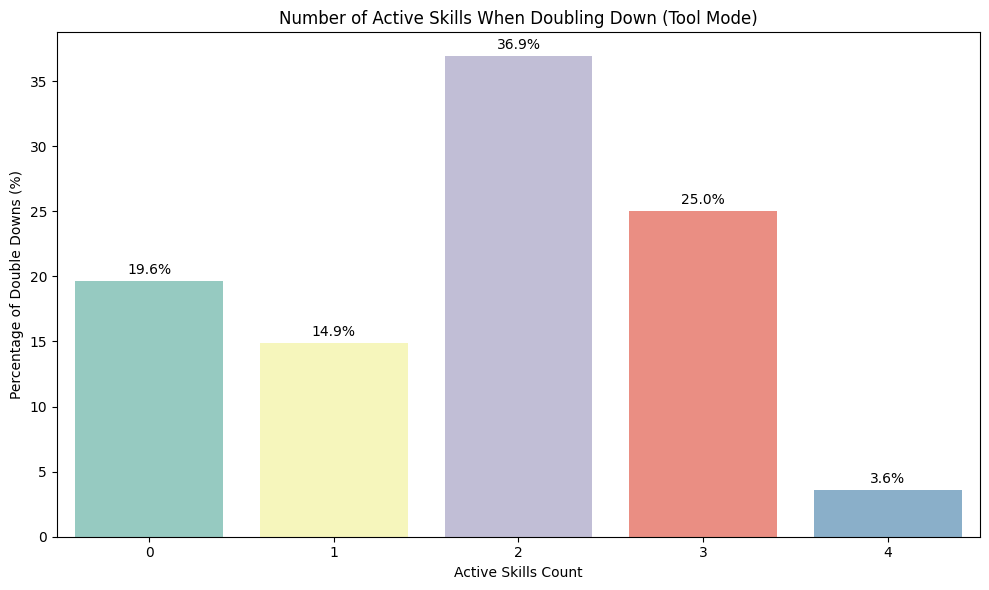

In [15]:
# ==========================================================
# 3. Active Skills Count During Double Down (Tool Mode)
# ==========================================================
skills_pct = df_dd_tool['active_skills_count'].value_counts(normalize=True).rename('Percentage').reset_index()
skills_pct['Percentage'] *= 100

plt.figure(figsize=(10, 6))
ax3 = sns.barplot(data=skills_pct, x='active_skills_count', y='Percentage', palette='Set3')
plt.title('Number of Active Skills When Doubling Down (Tool Mode)')
plt.xlabel('Active Skills Count')
plt.ylabel('Percentage of Double Downs (%)')
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

## 4.3 Tool Mode: Double Down vs Overall Baseline
Compares the category and level distribution of Double Down selections in Tool mode against the overall Tool mode baseline, using Fisher's Exact tests to identify statistically significant preferences.


--- Fisher's Exact Test: Tool Mode Categories (Baseline vs Double Down) ---


,Value,Baseline,Double Down,p-value,Significant
2,"Language, Linguistics & Cryptography",31/542 (5.7%),2/168 (1.2%),0.011313,Yes
0,Science & Mathematics,324/542 (59.8%),112/168 (66.7%),0.123128,No
3,Geography & Travel,17/542 (3.1%),3/168 (1.8%),0.435653,No
7,"Arts, Literature & Museums",20/542 (3.7%),8/168 (4.8%),0.502570,No
1,Technology & Computer Science,70/542 (12.9%),20/168 (11.9%),0.791809,No
4,Pop Culture & Entertainment,62/542 (11.4%),19/168 (11.3%),1.000000,No
5,History & Politics,15/542 (2.8%),4/168 (2.4%),1.000000,No
6,Other,3/542 (0.6%),0/168 (0.0%),1.000000,No


------------------------------------------------------------


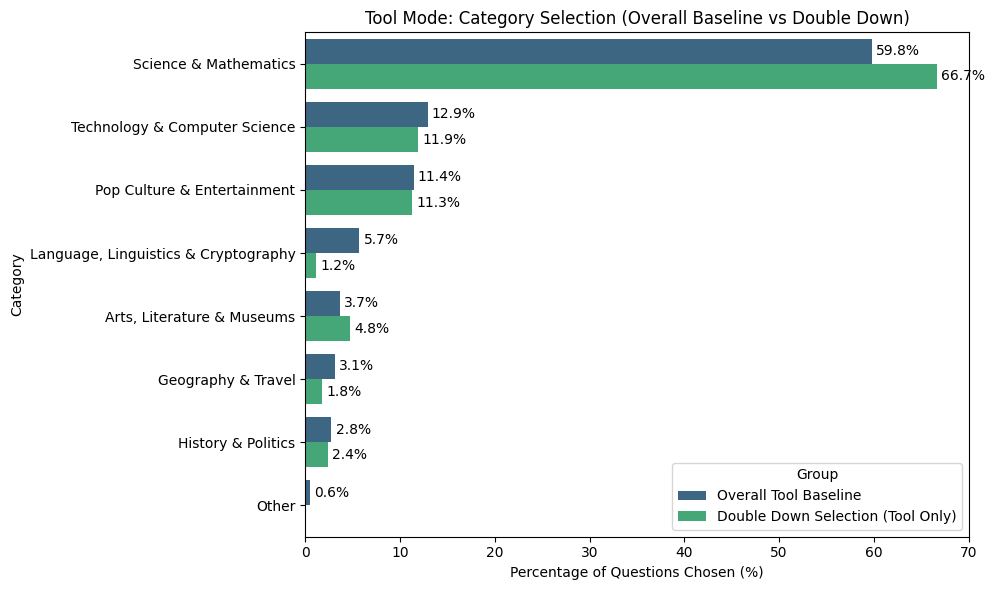


--- Fisher's Exact Test: Tool Mode Levels (Baseline vs Double Down) ---


,Value,Baseline,Double Down,p-value,Significant
0,1,150/542 (27.7%),31/168 (18.5%),0.019515,Yes
1,2,242/542 (44.6%),91/168 (54.2%),0.033792,Yes
2,3,150/542 (27.7%),46/168 (27.4%),1.000000,No


------------------------------------------------------------


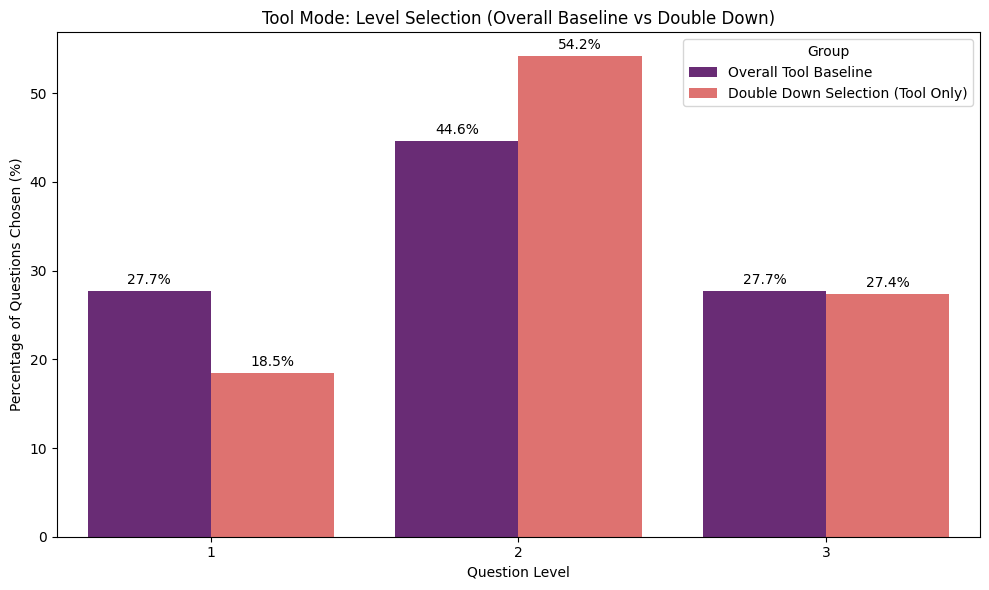

In [16]:
# ==========================================================
# 4. Tool Mode: Double Down vs Overall Baseline - CATEGORY
# ==========================================================
df_overall_cat = pd.DataFrame(all_tool_categories, columns=['category'])
overall_cat_counts = df_overall_cat['category'].value_counts(normalize=True).reset_index()
overall_cat_counts.columns = ['Category', 'Percentage']
overall_cat_counts['Group'] = 'Overall Tool Baseline'

dd_cat_counts = df_dd_tool['category'].value_counts(normalize=True).reset_index()
dd_cat_counts.columns = ['Category', 'Percentage']
dd_cat_counts['Group'] = 'Double Down Selection (Tool Only)'

# Fisher Test: Baseline vs Double Down (Tool Only) - Category
print_fisher_results(df_overall_cat['category'], df_dd_tool['category'], 'Baseline', 'Double Down', 'Tool Mode Categories')

combined_cat = pd.concat([overall_cat_counts, dd_cat_counts])
combined_cat['Percentage'] *= 100

plt.figure(figsize=(10, 6))
ax4 = sns.barplot(data=combined_cat, y='Category', x='Percentage', hue='Group', palette='viridis')
plt.title('Tool Mode: Category Selection (Overall Baseline vs Double Down)')
plt.xlabel('Percentage of Questions Chosen (%)')
plt.ylabel('Category')
for container in ax4.containers:
    ax4.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

# ==========================================================
# 5. Tool Mode: Double Down vs Overall Baseline - LEVEL
# ==========================================================
df_overall_lvl = pd.DataFrame(all_tool_levels, columns=['level'])
overall_lvl_counts = df_overall_lvl['level'].value_counts(normalize=True).reset_index()
overall_lvl_counts.columns = ['Level', 'Percentage']
overall_lvl_counts['Group'] = 'Overall Tool Baseline'

dd_lvl_counts = df_dd_tool['level'].value_counts(normalize=True).reset_index()
dd_lvl_counts.columns = ['Level', 'Percentage']
dd_lvl_counts['Group'] = 'Double Down Selection (Tool Only)'

# Fisher Test: Baseline vs Double Down (Tool Only) - Level
print_fisher_results(df_overall_lvl['level'], df_dd_tool['level'], 'Baseline', 'Double Down', 'Tool Mode Levels')

combined_lvl = pd.concat([overall_lvl_counts, dd_lvl_counts])
combined_lvl['Percentage'] *= 100

plt.figure(figsize=(10, 6))
ax5 = sns.barplot(data=combined_lvl, x='Level', y='Percentage', hue='Group', palette='magma')
plt.title('Tool Mode: Level Selection (Overall Baseline vs Double Down)')
plt.ylabel('Percentage of Questions Chosen (%)')
plt.xlabel('Question Level')
for container in ax5.containers:
    ax5.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

## 4.4 Overall Double Down Usage (Control vs Tool)
This section evaluates the raw and percentage usage of the Double Down ability across runs.

/tmp/ipykernel_9648/3292960385.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax6 = sns.barplot(data=dd_totals, x='Mode', y='Usage Percentage (%)', palette='Set2')


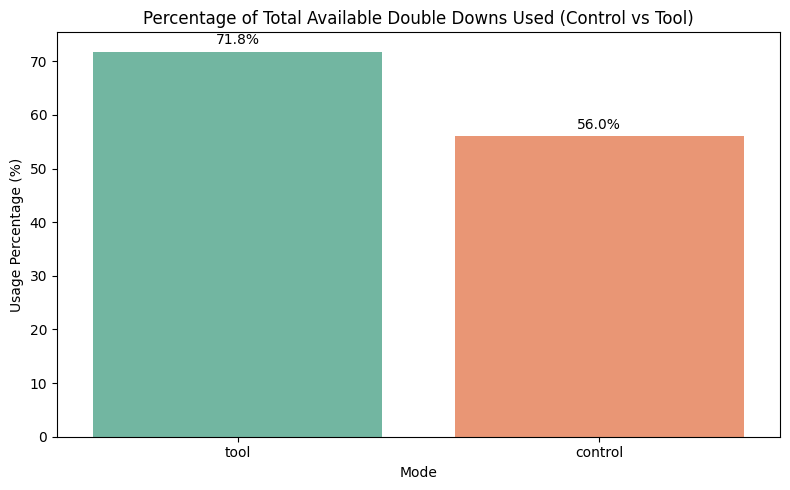

,Mode,Total Uses,Total Possible,Usage Percentage (%)
0,tool,168,234,71.794872
1,control,131,234,55.982906



--- Fisher's Exact Test: Overall Double Down Usage (Control vs Tool) ---
Control: 131/234 (56.0%)
Tool:    168/234 (71.8%)
p-value: 0.0005132724665608399
Significant: Yes
------------------------------------------------------------


In [17]:
# ==========================================================
# 6. Overall Total Double Down Usage (Control vs Tool)
# ==========================================================

# Calculate the total number of runs for each mode to find total opportunities
total_runs_control = sum(1 for r in all_data if r['mode'] == 'control')
total_runs_tool = sum(1 for r in all_data if r['mode'] == 'tool')

dd_totals = df_dd['mode'].value_counts().reset_index()
dd_totals.columns = ['Mode', 'Total Uses']

# Each run gives the agent exactly 3 double down opportunities
dd_totals['Total Possible'] = dd_totals['Mode'].apply(
    lambda m: (total_runs_tool * 3) if m == 'tool' else (total_runs_control * 3)
)
dd_totals['Usage Percentage (%)'] = (dd_totals['Total Uses'] / dd_totals['Total Possible']) * 100

plt.figure(figsize=(8, 5))
ax6 = sns.barplot(data=dd_totals, x='Mode', y='Usage Percentage (%)', palette='Set2')
plt.title('Percentage of Total Available Double Downs Used (Control vs Tool)')
plt.xlabel('Mode')
plt.ylabel('Usage Percentage (%)')
for container in ax6.containers:
    ax6.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

display(dd_totals)

# Fisher Exact Test for Overall Usage
total_uses_control = len(df_dd_control)
total_uses_tool = len(df_dd_tool)
total_possible_control = total_runs_control * 3
total_possible_tool = total_runs_tool * 3

table = [
    [total_uses_control, total_uses_tool],
    [total_possible_control - total_uses_control, total_possible_tool - total_uses_tool]
]

_, p_val = fisher_exact(table)

print("\n--- Fisher's Exact Test: Overall Double Down Usage (Control vs Tool) ---")
print(f"Control: {total_uses_control}/{total_possible_control} ({(total_uses_control/max(1, total_possible_control))*100:.1f}%)")
print(f"Tool:    {total_uses_tool}/{total_possible_tool} ({(total_uses_tool/max(1, total_possible_tool))*100:.1f}%)")
print(f"p-value: {p_val}")
print(f"Significant: {'Yes' if p_val < 0.05 else 'No'}")
print("-" * 60)

## 4.5 Accuracy on Double Downs — "Language, Linguistics & Cryptography"
This isolates questions in the "Language, Linguistics & Cryptography" category that the agent doubled down on and compares the accuracy breakdown between Control and Tool modes.

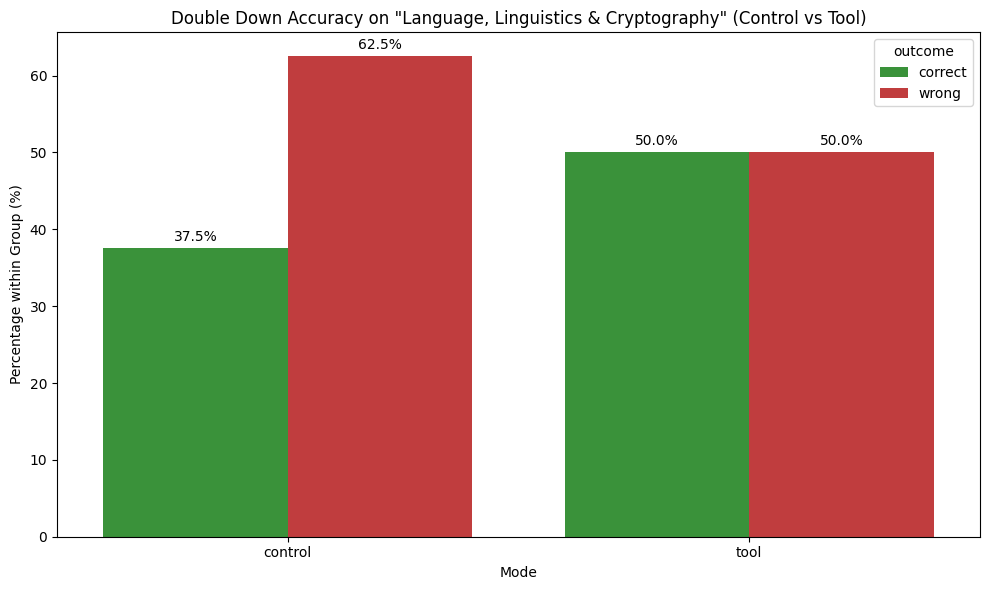

,mode,outcome,count,percentage
0,control,correct,3,37.5
1,control,wrong,5,62.5
2,tool,correct,1,50.0
3,tool,wrong,1,50.0


In [18]:
# ==========================================================
# 7. Accuracy on Double Downs ("Language, Linguistics & Cryptography")
# ==========================================================
CATEGORY_TARGET = "Language, Linguistics & Cryptography"

# Filter to where the agent doubled down on the target category
df_dd_lang = df_dd[df_dd['category'] == CATEGORY_TARGET]

if df_dd_lang.empty:
    print(f"No double down actions found for '{CATEGORY_TARGET}'.")
else:
    # Group by mode and calculate correct/wrong distributions
    lang_acc_counts = df_dd_lang.groupby(['mode', 'outcome']).size().reset_index(name='count')
    # Calculate percentage within each mode
    lang_acc_counts['percentage'] = lang_acc_counts['count'] / lang_acc_counts.groupby('mode')['count'].transform('sum') * 100

    plt.figure(figsize=(10, 6))
    ax7 = sns.barplot(
        data=lang_acc_counts, 
        x='mode', 
        y='percentage', 
        hue='outcome', 
        palette={'correct': '#2ca02c', 'wrong': '#d62728'}
    )
    plt.title(f'Double Down Accuracy on "{CATEGORY_TARGET}" (Control vs Tool)')
    plt.xlabel('Mode')
    plt.ylabel('Percentage within Group (%)')
    for container in ax7.containers:
        ax7.bar_label(container, fmt='%.1f%%', padding=3)
    plt.tight_layout()
    plt.show()

    display(lang_acc_counts)